In [2]:
import json
import numpy as np
import pandas as pd

## データの読み込み

In [3]:
apt_path = "atp_calculated_results/atp_results_gemma-2-9b-it_20251201_093733.json"
metrics_path = "results/shap_experiments/feature_selection_prompt_last_token_20251129_214443/data/feature_metrics_full.csv"

with open(apt_path, "r") as f:
    data_apt = json.load(f)

data_metrics = pd.read_csv(metrics_path)

In [4]:
data_metrics.head()

,Feature,Feature_ID,Freq Syc (%),Freq NonSyc (%),Freq Base (%),Freq Diff Base-Syc,Mean Intensity Syc,Mean Intensity NonSyc,Mean Intensity Base,Specificity,Consistency,Diff Base-Syc,Log Ratio Syc/Base,SHAP Correlation,Suppression Score,Amplification Score
0,feature_4,4,0.234632,0.208388,0.167504,0.067127,0.034953,0.026314,0.019840,0.529618,0.002346,0.015113,0.816998,NaN,0.000000,0.0
1,feature_9,9,9.760676,6.980985,7.035176,2.725500,1.085014,0.755802,0.759598,0.583017,0.097607,0.325416,0.514405,0.484589,0.009786,0.0
2,feature_13,13,0.469263,0.755405,0.670017,-0.200753,0.057200,0.102797,0.089180,0.383175,0.004693,-0.031980,-0.640691,NaN,0.000000,0.0
3,feature_16,16,0.046926,0.000000,0.000000,0.046926,0.004824,0.000000,0.000000,0.999979,0.000469,0.004824,12.236360,NaN,0.000000,0.0
4,feature_30,30,0.563116,0.651211,0.670017,-0.106901,0.061388,0.079242,0.082053,0.463726,0.005631,-0.020665,-0.418598,NaN,0.000000,0.0


## データ構造の確認


In [5]:
data_apt["results"][1]['variations'][2]["atp_analysis"]

{'top_features': [{'id': '962',
   'score': -0.02018841542303562,
   'activation': 51.85345458984375,
   'gradient': -0.0003893359680660069},
  {'id': '5262',
   'score': 0.016852401196956635,
   'activation': 57.849796295166016,
   'gradient': 0.0002913130447268486},
  {'id': '4871',
   'score': -0.013950607739388943,
   'activation': 46.04855728149414,
   'gradient': -0.0003029542858712375},
  {'id': '4346',
   'score': -0.013934318907558918,
   'activation': 44.03401184082031,
   'gradient': -0.00031644446426071227},
  {'id': '728',
   'score': -0.012961801141500473,
   'activation': 49.7763671875,
   'gradient': -0.00026040070224553347},
  {'id': '14225',
   'score': -0.012010045349597931,
   'activation': 34.279998779296875,
   'gradient': -0.0003503513871692121},
  {'id': '15407',
   'score': 0.007881815545260906,
   'activation': 23.117870330810547,
   'gradient': 0.0003409403725527227},
  {'id': '7109',
   'score': 0.006612129509449005,
   'activation': 19.924785614013672,
   '

## atpスコアの計算にエラーがないかのチェック

In [6]:
# atp_analysisにerrorが含まれているかをチェック
error_count = 0
error_details = []

for idx, result in enumerate(data_apt["results"]):
    question_id = result.get("question_id", idx)
    
    for var_idx, variation in enumerate(result.get("variations", [])):
        # baseテンプレート(template_type=="")はスキップ
        template_type = variation.get("template_type", "")
        if template_type == "":
            continue
        
        # sycophancy_flag==0の場合もスキップ
        sycophancy_flag = variation.get("sycophancy_flag", 0)
        if sycophancy_flag == 0:
            continue
            
        atp_analysis = variation.get("atp_analysis")
        
        # atp_analysisが存在しない場合
        if atp_analysis is None:
            error_count += 1
            error_details.append({
                "question_id": question_id,
                "variation_index": var_idx,
                "error_type": "missing_atp_analysis",
                "template": variation.get("template_type", "unknown")
            })
        # atp_analysisにerrorキーが含まれている場合
        elif isinstance(atp_analysis, dict) and "error" in atp_analysis:
            error_count += 1
            error_details.append({
                "question_id": question_id,
                "variation_index": var_idx,
                "error_type": "error_in_atp_analysis",
                "error_message": atp_analysis.get("error"),
                "template": variation.get("template_type", "unknown")
            })

print(f"Total errors found: {error_count}")
print(f"\nError details:")
for error in error_details:
    print(f"  Question ID: {error['question_id']}, Variation: {error['variation_index']}, "
          f"Template: {error.get('template')}, Type: {error['error_type']}")
    if "error_message" in error:
        print(f"    Error message: {error['error_message']}")

Total errors found: 0

Error details:


## 各SAE特徴ごとのATPスコア
- Global Mean Attribution：全迎合サンプル数でATPスコア合計を割る（←こちらを介入候補の選定では利用する）
- Conditional Mean Attribution：活性化した時の回数でATPスコアの合計を割る

In [7]:
# 各SAE特徴ごとのATPスコアを集計（Global Mean Attribution方式）

# Step 1: 全迎合サンプル数をカウント
total_sycophancy_samples = 0

for result in data_apt["results"]:
    for variation in result["variations"]:
        # baseテンプレートまたはsycophancy_flag==0の場合はスキップ
        if variation["template_type"] == "" or variation["sycophancy_flag"] == 0:
            continue
        
        atp_analysis = variation["atp_analysis"]
        if atp_analysis is None or "error" in atp_analysis:
            continue
        
        total_sycophancy_samples += 1

print(f"Total sycophancy samples (N_syc): {total_sycophancy_samples}")

# Step 2: 各特徴量のAtPスコア総和を計算（活性化しなかった場合は0として扱う）
feature_atp_sum = {}
feature_activation_count = {}  # 参考用：実際に活性化した回数

for result in data_apt["results"]:
    for variation in result["variations"]:
        # baseテンプレートまたはsycophancy_flag==0の場合はスキップ
        if variation["template_type"] == "" or variation["sycophancy_flag"] == 0:
            continue
        
        atp_analysis = variation["atp_analysis"]
        if atp_analysis is None or "error" in atp_analysis:
            continue
        
        # top_features（上位50個）からスコアを取得
        for feature_info in atp_analysis["top_features"]:
            feature_id = feature_info["id"]
            atp_score = feature_info["score"]
            
            if feature_id is not None and atp_score is not None:
                if feature_id not in feature_atp_sum:
                    feature_atp_sum[feature_id] = 0.0
                    feature_activation_count[feature_id] = 0
                
                feature_atp_sum[feature_id] += atp_score
                feature_activation_count[feature_id] += 1

# Step 3: Global Mean Attribution スコアを計算
atp_stats = []
for feature_id, total_score in feature_atp_sum.items():
    # Global Mean: 全迎合サンプル数で割る（非活性時は0として扱う）
    global_mean_score = total_score / total_sycophancy_samples
    
    # 参考値: 活性化した時のみの平均（Conditional Mean）
    conditional_mean_score = total_score / feature_activation_count[feature_id]
    
    atp_stats.append({
        'Feature_ID': feature_id,
        'Global_Mean_ATP': global_mean_score,  # 推奨指標
        'Conditional_Mean_ATP': conditional_mean_score,  # 参考値
        'Total_ATP_Sum': total_score,
        'Activation_Count': feature_activation_count[feature_id],
        'Activation_Rate': feature_activation_count[feature_id] / total_sycophancy_samples
    })

# データフレーム化してGlobal_Mean_ATPでソート
df_atp_scores = pd.DataFrame(atp_stats).sort_values('Global_Mean_ATP', ascending=False).reset_index(drop=True)

print(f"\nTop 10 features by Global Mean ATP Score:")
df_atp_scores.head(10)

Total sycophancy samples (N_syc): 145

Top 10 features by Global Mean ATP Score:


,Feature_ID,Global_Mean_ATP,Conditional_Mean_ATP,Total_ATP_Sum,Activation_Count,Activation_Rate
0,5262,0.009069,0.010691,1.314936,123,0.848276
1,3034,0.004980,0.006877,0.722049,105,0.724138
2,15407,0.004290,0.006480,0.622087,96,0.662069
3,11797,0.003045,0.021023,0.441480,21,0.144828
4,550,0.003015,0.043720,0.437195,10,0.068966
5,14708,0.002917,0.008460,0.423004,50,0.344828
6,481,0.002894,0.005671,0.419650,74,0.510345
7,5090,0.002821,0.005603,0.408992,73,0.503448
8,12506,0.002732,0.030470,0.396113,13,0.089655
9,10044,0.002672,0.002914,0.387508,133,0.917241


## Global Mean vs Conditional Mean の比較

Global Mean（推奨）とConditional Mean（従来方式）の違いを可視化します。
頻度と強度のバランスが正しく評価されているか確認しましょう。

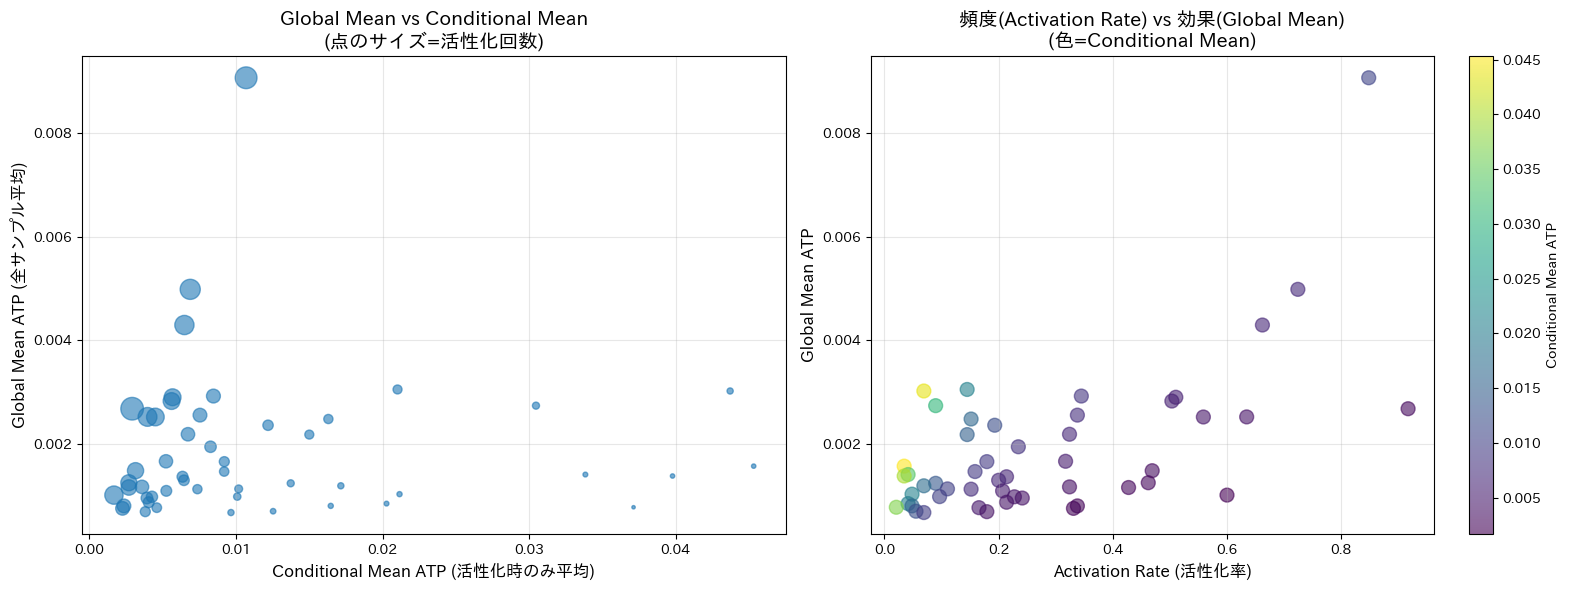

レアケース（低頻度だが高スコア）の特徴を確認:
    Feature_ID  Global_Mean_ATP  Conditional_Mean_ATP  Total_ATP_Sum  \
58        5003         0.000552              0.080035       0.080035   
50       11053         0.000644              0.046680       0.093360   
91        8911         0.000316              0.045797       0.045797   
20        1794         0.001563              0.045327       0.226635   
4          550         0.003015              0.043720       0.437195   
54       12909         0.000598              0.043334       0.086669   
24         578         0.001372              0.039789       0.198946   
44       10738         0.000768              0.037128       0.111385   
111       8368         0.000237              0.034435       0.034435   
23        6817         0.001400              0.033841       0.203046   

     Activation_Count  Activation_Rate  
58                  1         0.006897  
50                  2         0.013793  
91                  1         0.006897  
20                 

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# 上位50特徴を抽出して比較
top_n = 50
df_top = df_atp_scores.head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Global Mean vs Conditional Mean
axes[0].scatter(df_top['Conditional_Mean_ATP'], df_top['Global_Mean_ATP'], 
                alpha=0.6, s=df_top['Activation_Count']*2)
axes[0].set_xlabel('Conditional Mean ATP (活性化時のみ平均)', fontsize=12)
axes[0].set_ylabel('Global Mean ATP (全サンプル平均)', fontsize=12)
axes[0].set_title('Global Mean vs Conditional Mean\n(点のサイズ=活性化回数)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Plot 2: Activation Rate vs Global Mean
axes[1].scatter(df_top['Activation_Rate'], df_top['Global_Mean_ATP'], 
                alpha=0.6, c=df_top['Conditional_Mean_ATP'], cmap='viridis', s=100)
axes[1].set_xlabel('Activation Rate (活性化率)', fontsize=12)
axes[1].set_ylabel('Global Mean ATP', fontsize=12)
axes[1].set_title('頻度(Activation Rate) vs 効果(Global Mean)\n(色=Conditional Mean)', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Conditional Mean ATP')

plt.tight_layout()
plt.show()

print("レアケース（低頻度だが高スコア）の特徴を確認:")
print(df_atp_scores[df_atp_scores['Activation_Rate'] < 0.1].sort_values('Conditional_Mean_ATP', ascending=False).head(10))

## ATPスコアと各特徴の特異性の可視化

In [9]:
df_atp_scores.describe()

,Global_Mean_ATP,Conditional_Mean_ATP,Total_ATP_Sum,Activation_Count,Activation_Rate
count,6.730000e+02,673.000000,673.000000,673.00000,673.000000
mean,-4.074293e-07,0.000637,-0.000059,10.77266,0.074294
std,9.619494e-04,0.010808,0.139483,21.09369,0.145474
min,-8.855621e-03,-0.061833,-1.284065,1.00000,0.006897
25%,-1.032822e-04,-0.004367,-0.014976,1.00000,0.006897
50%,-9.821917e-06,-0.000646,-0.001424,3.00000,0.020690
75%,1.243444e-04,0.004837,0.018030,9.00000,0.062069
max,9.068525e-03,0.080035,1.314936,139.00000,0.958621


In [10]:
# 結語するためにデータ型を変更
df_atp_scores["Feature_ID"] = df_atp_scores["Feature_ID"].astype(int)

base_metrics = data_metrics[["Feature_ID", "Specificity", "Log Ratio Syc/Base"]].copy()
df_plot_data = pd.merge(df_atp_scores, base_metrics, on="Feature_ID", how="left")

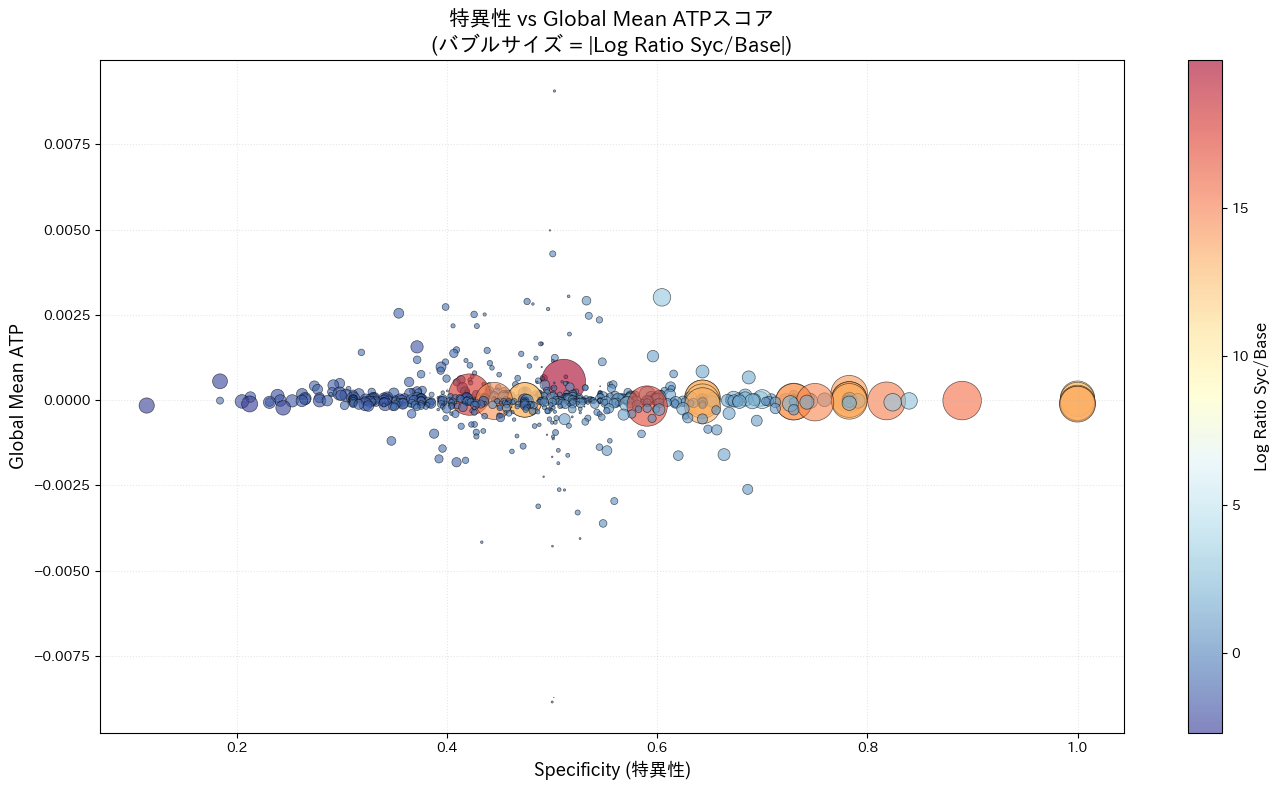

=== 上位30特徴の統計サマリー ===
Specificity 平均: 0.4666
Log Ratio Syc/Base 平均: -0.0039
Conditional Mean ATP 平均: 0.013616


In [16]:
# 上位30特徴を取得
top_30_features = df_plot_data.nlargest(30, 'Global_Mean_ATP')

# プロット作成
fig, ax = plt.subplots(figsize=(14, 8))

# Log Ratio Syc/Baseを使ってバブルサイズとカラーマップを設定
# サイズは絶対値を使用（負の値も表現できるように）
bubble_sizes = np.abs(df_plot_data['Log Ratio Syc/Base']) * 50  # スケーリング係数は調整可能

# 散布図
scatter = ax.scatter(
    df_plot_data['Specificity'], 
    df_plot_data['Global_Mean_ATP'],
    s=bubble_sizes,
    c=df_plot_data['Log Ratio Syc/Base'],
    cmap='RdYlBu_r',  # 赤(高い) → 黄 → 青(低い)
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# 上位30特徴に補助線を引く
# for _, row in top_30_features.iterrows():
#     ax.plot(
#         [row['Specificity'], row['Specificity']], 
#         [ax.get_ylim()[0], row['Global_Mean_ATP']],
#         color='gray', 
#         linestyle='--', 
#         linewidth=0.8, 
#         alpha=0.4
#     )

# カラーバー
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Log Ratio Syc/Base', fontsize=12)

# ラベルとタイトル
ax.set_xlabel('Specificity (特異性)', fontsize=13)
ax.set_ylabel('Global Mean ATP', fontsize=13)
ax.set_title('特異性 vs Global Mean ATPスコア\n(バブルサイズ = |Log Ratio Syc/Base|)', fontsize=15, fontweight='bold')

# グリッド
ax.grid(True, alpha=0.3, linestyle=':')

# レイアウト調整
plt.tight_layout()
plt.show()

# 上位30特徴の統計情報を表示
print("=== 上位30特徴の統計サマリー ===")
print(f"Specificity 平均: {top_30_features['Specificity'].mean():.4f}")
print(f"Log Ratio Syc/Base 平均: {top_30_features['Log Ratio Syc/Base'].mean():.4f}")
print(f"Conditional Mean ATP 平均: {top_30_features['Conditional_Mean_ATP'].mean():.6f}")

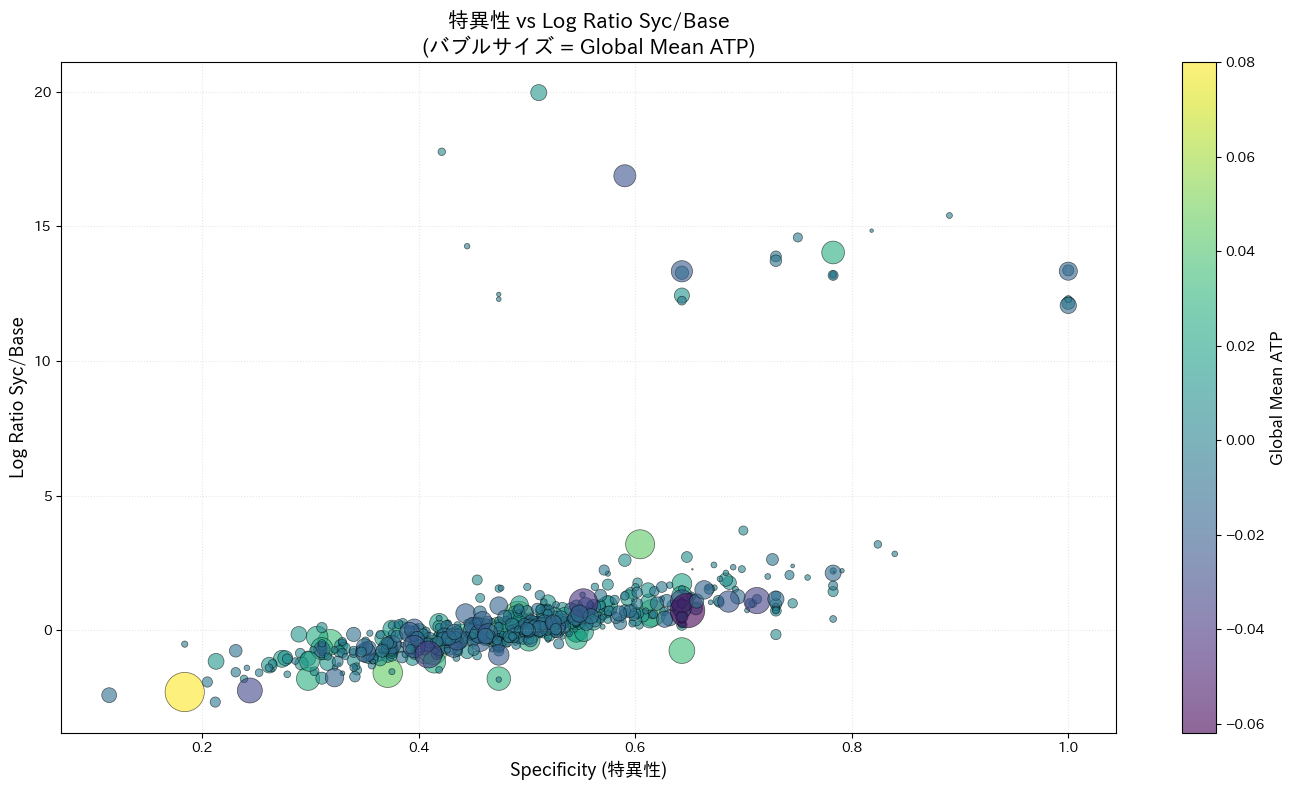

In [15]:
# 散布図の作成
fig, ax = plt.subplots(figsize=(14, 8))

# バブルサイズの設定（Global Mean ATPの絶対値を使用）
bubble_sizes = np.abs(df_plot_data['Conditional_Mean_ATP']) * 10000  # スケーリング係数は調整可能

# 散布図
scatter = ax.scatter(
    df_plot_data['Specificity'], 
    df_plot_data['Log Ratio Syc/Base'],
    s=bubble_sizes,
    c=df_plot_data['Conditional_Mean_ATP'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# カラーバー
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Global Mean ATP', fontsize=12)

# ラベルとタイトル
ax.set_xlabel('Specificity (特異性)', fontsize=13)
ax.set_ylabel('Log Ratio Syc/Base', fontsize=13)
ax.set_title('特異性 vs Log Ratio Syc/Base\n(バブルサイズ = Global Mean ATP)', fontsize=15, fontweight='bold')

# グリッド
ax.grid(True, alpha=0.3, linestyle=':')

# レイアウト調整
plt.tight_layout()
plt.show()